<a href="https://colab.research.google.com/github/Gatwaza/Capstone-Project/blob/main/CPR_Coach_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPR-Coach · Multi-Task Assessment · TensorFlow/Keras
**Capstone — ML First Aid Simulation Training Tool**  
Jean Robert Gatwaza · African Leadership University · 2026

---
| Stage | Description |
|---|---|
| 1 | Drive mount, paths, GPU |
| 2 | Annotation parsing (correct format from your actual files) |
| 3 | PKL keypoint loading + key matching |
| 4 | Biomechanical feature engineering (12 features) |
| 5 | Class imbalance analysis + sample weights |
| 6 | Train / Val / Test split 70-15-15 |
| 7 | 7 TensorFlow model definitions |
| 8 | Hyperparameter grid + **resumable** training loop |
| 9 | Per-class F1, AUC-ROC, confusion matrices |
| 10 | TFLite INT8 export + CPU latency benchmark |
| 11 | Final summary report |


## 🔧 Fixes Applied (v2)

| # | Location | Bug | Fix |
|---|----------|-----|-----|
| 1 | Stage 5 | Class weights computed on full dataset before split — data leakage | Moved class weight computation to Stage 6, computed from training labels only |
| 2 | Stage 5 | Recoil weights inverted: Complete=1.57, Incomplete=0.73 (Incomplete is actually majority) | Recomputed from training split — now correctly weighted |
| 3 | Stage 6 | `stratify=y_rate` only — no guarantee depth/recoil stay balanced | Kept `stratify=y_rate`; also added combined label for diagnostics |
| 4 | Stage 6 | `sample_weight` passed as a **dict** to `model.fit()` — silently ignored by Keras for multi-output models | Changed to a plain 1-D `numpy` array |
| 5 | Stage 8 | Recoil `loss_weight` was 0.5–1.0 while depth was 2.0–2.5 — model ignored recoil | Raised recoil `loss_weight` to **2.0** across all configs |
| 6 | Stage 8 | Plain `CategoricalCrossentropy` cannot handle severe class imbalance | Replaced with **FocalCrossEntropy** (γ=2.0, label_smoothing=0.05) |
| 7 | Stage 8 | `except Exception: break` stops entire sweep on any failure | Changed to `continue` so remaining models still train |
| 8 | Stage 9 | `preds[i]` (integer index) fails — model returns a **dict** | Fixed to `preds[task]` (key-based indexing) |
| 9 | Stage 9 | Confusion matrix used same integer indexing bug | Fixed to `preds[task]` |


## STAGE 1 — Environment Setup

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os, pickle, re, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, metrics

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

# ── GPU ──────────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow : {tf.__version__}')
print(f'GPUs       : {len(gpus)}')
if gpus:
    print(f'GPU name   : {tf.test.gpu_device_name()}')
    tf.config.experimental.set_memory_growth(gpus[0], True)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT      = Path('/content/drive/MyDrive/cpr_coach_data')
KEYPOINTS_DIR  = DATA_ROOT / 'Keypoints'
ANN_DIR        = DATA_ROOT / 'ann'
CHECKPOINT_DIR = Path('/content/drive/MyDrive/cpr_coach_checkpoints_tf')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ── Resume state file (tracks which models are already done) ─────────────────
RESUME_FILE = CHECKPOINT_DIR / 'resume_state.json'

print(f'Data root      : {DATA_ROOT}')
print(f'Keypoints dir  : {KEYPOINTS_DIR}')
print(f'Annotation dir : {ANN_DIR}')
print(f'Checkpoint dir : {CHECKPOINT_DIR}')
print('\n✓ Stage 1 complete')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow : 2.20.0
GPUs       : 0
Data root      : /content/drive/MyDrive/cpr_coach_data
Keypoints dir  : /content/drive/MyDrive/cpr_coach_data/Keypoints
Annotation dir : /content/drive/MyDrive/cpr_coach_data/ann
Checkpoint dir : /content/drive/MyDrive/cpr_coach_checkpoints_tf

✓ Stage 1 complete


## STAGE 2 — Annotation Parsing (Actual Format)

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# ACTION LIST STRUCTURE (from your actual ActionList.txt)
#
# Line indices (1-based) → error descriptions:
#   1  = Correct
#   2  = Overlap Hands          → hand position error  → recoil=Incomplete
#   3  = Clenching Hands        → hand position error  → recoil=Incomplete
#   4  = Single Hand            → hand position error  → recoil=Incomplete
#   5  = Bending Arms           → elbow error          → recoil=Incomplete
#   6  = Tilting Arms           → posture error        → recoil=Incomplete
#   7  = Jump Pressing          → posture/rate error   → rate=Too_Fast
#   8  = Squatting              → posture error        → recoil=Incomplete
#   9  = Standing               → posture error        → recoil=Incomplete
#   10 = Wrong Position         → hand position error  → recoil=Incomplete
#   11 = Insufficient Pressing  → depth error          → depth=Too_Shallow
#   12 = Slow Frequency         → rate error           → rate=Too_Slow
#   13 = Excessive Pressing     → depth error          → depth=Too_Deep
#   14 = Random Position        → hand position error  → recoil=Incomplete
#
# Annotation file formats:
#   trainlist.txt / testlist.txt:
#     <video_path> <numeric_id> <attribute_id>
#     e.g.  CPR_Dataset_S0/C00_S0/r00/ch0  286  0
#     attribute_id=0 → index into doubleClsList OR single-class ID
#
#   all_errors / double_errors / triquad:
#     <video_path> <numeric_id> <class_label> <attribute_id> [<attr2> ...]
#     e.g.  CPR_Double_Dataset_S0/DC00_S0/r00/ch0  381  1  4
#     class_label=1, attribute_id=4 → doubleClsList["4"] = (1,8)
# ─────────────────────────────────────────────────────────────────────────────

# ── Hard-coded doubleClsList from your ActionList.txt ────────────────────────
DOUBLE_CLS = {
    0:(1,4),  1:(1,5),  2:(1,6),  3:(1,7),  4:(1,8),  5:(1,9),
    6:(1,10), 7:(1,11), 8:(1,12), 9:(1,13), 10:(2,6), 11:(2,7),
    12:(2,8), 13:(2,9), 14:(2,10),15:(2,11),16:(2,12),17:(3,6),
    18:(3,7), 19:(3,8), 20:(3,9), 21:(3,10),22:(3,11),23:(3,13),
    24:(4,5), 25:(4,6), 26:(4,7), 27:(4,8), 28:(4,9), 29:(4,10),
    30:(4,11),31:(4,13),32:(5,7), 33:(5,8), 34:(5,9), 35:(5,10),
    36:(5,11),37:(5,13),38:(6,7), 39:(6,8), 40:(6,9), 41:(6,10),
    42:(6,11),43:(6,12),44:(7,9), 45:(7,10),46:(7,11),47:(7,12),
    48:(7,13),49:(8,9), 50:(8,10),51:(8,11),52:(8,12),53:(8,13),
    54:(9,10),55:(9,11),56:(10,11),57:(10,12),58:(10,13)
}

# Map single error index → (rate, depth, recoil) labels
def single_error_to_labels(idx):
    """
    idx: 1-based action list index
    Returns (rate_label, depth_label, recoil_label)
    """
    if idx == 1:  return 'Correct',   'Correct',     'Complete'
    if idx == 7:  return 'Too_Fast',  'Correct',     'Incomplete'  # Jump Pressing
    if idx == 12: return 'Too_Slow',  'Correct',     'Complete'    # Slow Frequency
    if idx == 11: return 'Correct',   'Too_Shallow', 'Complete'    # Insufficient
    if idx == 13: return 'Correct',   'Too_Deep',    'Complete'    # Excessive
    # Everything else is a posture / hand / position error → recoil incomplete
    return 'Correct', 'Correct', 'Incomplete'

def error_tuple_to_labels(error_tuple):
    """
    Combine labels from a tuple of single error indices.
    Worst-case wins per dimension.
    """
    rate, depth, recoil = 'Correct', 'Correct', 'Complete'
    for idx in error_tuple:
        r, d, rc = single_error_to_labels(idx)
        if r   != 'Correct':  rate   = r
        if d   != 'Correct':  depth  = d
        if rc  != 'Complete': recoil = rc
    return rate, depth, recoil


def parse_ann_line(parts):
    """
    Parse one annotation line into (video_path, rate, depth, recoil).
    Handles both 3-column (trainlist) and 4/5-column (multi-error) formats.
    """
    video_path = parts[0]
    # numeric_id = parts[1]  # not used for labels

    if len(parts) == 3:
        # trainlist / testlist: <path> <id> <attr_id>
        attr_id = int(parts[2])
        if attr_id == 0:
            # Correct action
            return video_path, 'Correct', 'Correct', 'Complete'
        else:
            # Single-class error: attr_id is 1-based action index
            r, d, rc = single_error_to_labels(attr_id)
            return video_path, r, d, rc

    elif len(parts) >= 4:
        # Multi-error lists: <path> <id> <class_label> <attr_id> [<attr2>...]
        # attr_id here is key into DOUBLE_CLS
        attr_id = int(parts[3])
        error_tuple = DOUBLE_CLS.get(attr_id, (1,))  # fallback = Correct

        # If triquad: additional error indices follow
        extra = [int(p) for p in parts[4:] if p.isdigit()]
        if extra:
            error_tuple = error_tuple + tuple(extra)

        r, d, rc = error_tuple_to_labels(error_tuple)
        return video_path, r, d, rc

    return None


def load_all_annotations(ann_dir):
    """
    Load every txt file (except ActionList.txt) and return a single DataFrame.
    Excludes optical-flow lists (*_of.txt) since we use skeleton keypoints.
    """
    records = []
    skip = {'ActionList.txt', 'trainlist_of.txt', 'testlist_of.txt'}

    for f in sorted(ann_dir.glob('*.txt')):
        if f.name in skip:
            continue
        source = f.stem
        with open(f) as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) < 3:
                    continue
                result = parse_ann_line(parts)
                if result:
                    records.append(result + (source,))

    df = pd.DataFrame(records,
                      columns=['video_path','rate','depth','recoil','source'])
    # Keep one entry per video path (trainlist takes priority over test)
    df = df.drop_duplicates(subset='video_path', keep='first').reset_index(drop=True)
    return df


ann_df = load_all_annotations(ANN_DIR)
print(f'Total annotated sequences : {len(ann_df)}')
print(f'\nSource breakdown:')
print(ann_df['source'].value_counts().to_string())
print(f'\nRate  distribution:')
print(ann_df['rate'].value_counts().to_string())
print(f'\nDepth distribution:')
print(ann_df['depth'].value_counts().to_string())
print(f'\nRecoil distribution:')
print(ann_df['recoil'].value_counts().to_string())
print('\n✓ Stage 2 complete')

Total annotated sequences : 5664

Source breakdown:
source
all_errors_testlist    3312
trainlist              1344
testlist               1008

Rate  distribution:
rate
Correct     4528
Too_Fast     648
Too_Slow     488

Depth distribution:
depth
Correct        4656
Too_Deep        552
Too_Shallow     456

Recoil distribution:
recoil
Incomplete    3864
Complete      1800

✓ Stage 2 complete


## STAGE 3 — PKL Loading + Key Matching

In [14]:
import pickle

def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

print('Loading pkl files...')
train_kps = load_pkl(KEYPOINTS_DIR / 'train_keypoints.pkl')
test_kps  = load_pkl(KEYPOINTS_DIR / 'test_keypoints.pkl')

for label, kps in [('train', train_kps), ('test', test_kps)]:
    print(f'\n{label}_keypoints.pkl')
    print(f'  count : {len(kps)}')
    if kps:
        item = kps[0]
        if isinstance(item, dict):
            print(f'  keys       : {list(item.keys())}')
            print(f'  frame_dir  : {item.get("frame_dir", "N/A")}')
            if 'keypoint' in item:
                print(f'  kp shape   : {np.array(item["keypoint"]).shape}')

all_kps = {}
for kps_list in [train_kps, test_kps]:
    for item in kps_list:
        if isinstance(item, dict) and 'frame_dir' in item and 'keypoint' in item:
            all_kps[item['frame_dir']] = item['keypoint']

print(f'\nUnique physical videos in PKL : {len(all_kps)}')

print('\nSample raw PKL frame_dir keys:')
for k in list(all_kps.keys())[:8]:
    print(f'  {k!r}')

print('\nSample raw annotation video_path values:')
for p in ann_df['video_path'].head(8).tolist():
    print(f'  {p!r}')

def strip_key(k):
    return str(k).lstrip('./').strip()

pkl_exact = {strip_key(k): k for k in all_kps.keys()}
ann_df['key_norm'] = ann_df['video_path'].apply(strip_key)
matched = ann_df['key_norm'].isin(pkl_exact)
print(f'\nExact-path match   : {matched.sum()} / {len(ann_df)}')

if matched.sum() < len(all_kps) * 0.5:
    def suffix3(k):
        parts = strip_key(k).replace('\\', '/').split('/')
        return '/'.join(parts[-3:]) if len(parts) >= 3 else strip_key(k)
    pkl_s3  = {suffix3(k): k for k in all_kps.keys()}
    ann_df['key_norm'] = ann_df['video_path'].apply(suffix3)
    matched = ann_df['key_norm'].isin(pkl_s3)
    pkl_exact = pkl_s3
    print(f'3-part suffix match: {matched.sum()} / {len(ann_df)}')

if matched.sum() < len(all_kps) * 0.5:
    def suffix2(k):
        parts = strip_key(k).replace('\\', '/').split('/')
        return '/'.join(parts[-2:]) if len(parts) >= 2 else strip_key(k)
    pkl_s2  = {suffix2(k): k for k in all_kps.keys()}
    ann_df['key_norm'] = ann_df['video_path'].apply(suffix2)
    matched = ann_df['key_norm'].isin(pkl_s2)
    pkl_exact = pkl_s2
    print(f'2-part suffix match: {matched.sum()} / {len(ann_df)}')
    print('⚠ WARNING: 2-part keys cause collisions across datasets.')
    print('  Multiple annotations will map to the same physical video.')
    print('  EDA below will detect and deduplicate these.')

pkl_norm    = pkl_exact
ann_matched = ann_df[matched].copy()
print(f'\nProceeding with {len(ann_matched)} matched annotation rows')
print(f'Unique matched keys : {ann_matched["key_norm"].nunique()}')
if ann_matched["key_norm"].nunique() < len(ann_matched):
    n_dup = len(ann_matched) - ann_matched["key_norm"].nunique()
    print(f'⚠ {n_dup} annotation rows share a PKL key — EDA will resolve.')
print('\n✓ Stage 3 complete')

Loading pkl files...

train_keypoints.pkl
  count : 1344
  keys       : ['label', 'frame_dir', 'img_shape', 'original_shape', 'keypoint', 'keypoint_score', 'total_frames']
  frame_dir  : CPR_Dataset_S0_BIG/C00_S0/r00/ch0
  kp shape   : (1, 286, 68, 2)

test_keypoints.pkl
  count : 1008
  keys       : ['label', 'frame_dir', 'img_shape', 'original_shape', 'keypoint', 'keypoint_score', 'total_frames']
  frame_dir  : CPR_Dataset_S0_BIG/C00_S0/r11/ch0
  kp shape   : (1, 293, 68, 2)

Unique physical videos in PKL : 2352

Sample raw PKL frame_dir keys:
  'CPR_Dataset_S0_BIG/C00_S0/r00/ch0'
  'CPR_Dataset_S0_BIG/C00_S0/r00/ch1'
  'CPR_Dataset_S0_BIG/C00_S0/r00/ch2'
  'CPR_Dataset_S0_BIG/C00_S0/r00/ch3'
  'CPR_Dataset_S0_BIG/C00_S0/r01/ch0'
  'CPR_Dataset_S0_BIG/C00_S0/r01/ch1'
  'CPR_Dataset_S0_BIG/C00_S0/r01/ch2'
  'CPR_Dataset_S0_BIG/C00_S0/r01/ch3'

Sample raw annotation video_path values:
  'CPR_Double_Dataset_S0/DC00_S0/r00/ch0'
  'CPR_Double_Dataset_S0/DC00_S0/r00/ch1'
  'CPR_Double_Data

New Cell — Stage 3.5 EDA (insert after Cell 6, before Stage 4)

In [15]:
print('='*65)
print('EDA 1 — KEY COLLISION AUDIT')
print('='*65)
collision = ann_matched.groupby('key_norm').size()
multi     = collision[collision > 1]
print(f'Annotation rows               : {len(ann_matched)}')
print(f'Unique PKL keys               : {len(all_kps)}')
print(f'Unique matched annotation keys: {ann_matched["key_norm"].nunique()}')
print(f'PKL keys with >1 annotation   : {len(multi)}')

if len(multi) > 0:
    print('\nSample collisions (same physical video, multiple annotation rows):')
    for key in multi.index[:4]:
        rows = ann_matched[ann_matched['key_norm'] == key][
            ['source', 'video_path', 'rate', 'depth', 'recoil']]
        print(f'\n  PKL key: {key!r}')
        print(rows.to_string(index=False))
    print(f'\n→ Resolution: keep first annotation per key (train > test priority).')
    print(f'  Before dedup: {len(ann_matched)} rows')
    ann_matched = (ann_matched
                   .sort_values('source',
                                key=lambda s: s.map({'trainlist':0,'testlist':1,
                                                     'all_errors_testlist':2}).fillna(3))
                   .drop_duplicates(subset='key_norm', keep='first')
                   .reset_index(drop=True))
    print(f'  After dedup : {len(ann_matched)} rows  ← true dataset size')
else:
    print('✓ No collisions.')

print('\n' + '='*65)
print('EDA 2 — TRUE LABEL DISTRIBUTION (post-dedup)')
print('='*65)
for col in ['rate', 'depth', 'recoil']:
    vc = ann_matched[col].value_counts()
    print(f'\n{col}:')
    for cls, n in vc.items():
        bar = '█' * (n * 35 // vc.max())
        print(f'  {cls:15s}  {n:5d}  ({100*n/len(ann_matched):5.1f}%)  {bar}')

print('\n' + '='*65)
print('EDA 3 — LABEL DISTRIBUTION PER SOURCE FILE')
print('='*65)
for col in ['rate', 'depth', 'recoil']:
    print(f'\n{col.upper()} × source:')
    print(pd.crosstab(ann_matched['source'], ann_matched[col], margins=True).to_string())

print('\n' + '='*65)
print('EDA 4 — LABEL CO-OCCURRENCE')
print('='*65)
print('Rate × Depth:')
print(pd.crosstab(ann_matched['rate'], ann_matched['depth'], margins=True).to_string())
print('\nRate × Recoil:')
print(pd.crosstab(ann_matched['rate'], ann_matched['recoil'], margins=True).to_string())
print('\nDepth × Recoil:')
print(pd.crosstab(ann_matched['depth'], ann_matched['recoil'], margins=True).to_string())

print('\n' + '='*65)
print('EDA 5 — SEQUENCE LENGTH DISTRIBUTION')
print('='*65)
frame_counts = []
for row in ann_matched.itertuples():
    raw_key = pkl_norm.get(row.key_norm)
    if raw_key is None:
        continue
    arr = np.array(all_kps[raw_key], dtype=np.float32)
    if arr.ndim == 4:
        arr = arr.squeeze(0)
    frame_counts.append(arr.shape[0])

fc = np.array(frame_counts)
print(f'n={len(fc)}  min={fc.min()}  median={np.median(fc):.0f}  '
      f'mean={fc.mean():.0f}  max={fc.max()}  std={fc.std():.1f}')
bins  = [0,30,60,90,120,150,200,9999]
blbls = ['<30','30-60','60-90','90-120','120-150','150-200','>200']
hist,_ = np.histogram(fc, bins=bins)
for lbl, cnt in zip(blbls, hist):
    bar = '█' * (cnt * 40 // (hist.max()+1))
    print(f'  {lbl:>10}  {cnt:4d}  {bar}')
pct_short = 100*(fc < 60).sum()/len(fc)
print(f'\nSEQ_LEN=60. Sequences shorter: {(fc<60).sum()} ({pct_short:.1f}%)')
if pct_short > 20:
    print(f'⚠ Consider lowering SEQ_LEN to ~{int(np.percentile(fc,25))} (25th pct).')

print('\n' + '='*65)
print('EDA 6 — RECOIL ENCODING DIRECTION CHECK')
print('='*65)
_enc = LabelEncoder().fit(ann_matched['recoil'].tolist())
_y   = _enc.transform(ann_matched['recoil'].tolist())
_w   = compute_class_weight('balanced', classes=np.unique(_y), y=_y)
for i, (cls, w) in enumerate(zip(_enc.classes_, _w)):
    n   = (ann_matched['recoil'] == cls).sum()
    tag = 'MAJORITY → weight must be <1.0' if n > len(ann_matched)//2 else 'minority → weight >1.0'
    ok  = '✓' if (n > len(ann_matched)//2 and w < 1.0) or \
                  (n <= len(ann_matched)//2 and w > 1.0) else '✗ INVERTED'
    print(f'  {i} → {cls:12s}  n={n:5d}  weight={w:.3f}  {tag}  {ok}')

print('\n✓ Stage 3.5 EDA complete — review before running Stage 4')

EDA 1 — KEY COLLISION AUDIT
Annotation rows               : 2352
Unique PKL keys               : 2352
Unique matched annotation keys: 2352
PKL keys with >1 annotation   : 0
✓ No collisions.

EDA 2 — TRUE LABEL DISTRIBUTION (post-dedup)

rate:
  Correct           2016  ( 85.7%)  ███████████████████████████████████
  Too_Fast           168  (  7.1%)  ██
  Too_Slow           168  (  7.1%)  ██

depth:
  Correct           2016  ( 85.7%)  ███████████████████████████████████
  Too_Shallow        168  (  7.1%)  ██
  Too_Deep           168  (  7.1%)  ██

recoil:
  Incomplete        1512  ( 64.3%)  ███████████████████████████████████
  Complete           840  ( 35.7%)  ███████████████████

EDA 3 — LABEL DISTRIBUTION PER SOURCE FILE

RATE × source:
rate       Correct  Too_Fast  Too_Slow   All
source                                      
testlist       864        72        72  1008
trainlist     1152        96        96  1344
All           2016       168       168  2352

DEPTH × source:
depth     

## STAGE 4 — Biomechanical Feature Engineering (12 Features)

In [16]:
# ── AlphaPose COCO-17 joint indices ──────────────────────────────────────────
J = dict(nose=0, l_shoulder=5, r_shoulder=6,
         l_elbow=7, r_elbow=8, l_wrist=9, r_wrist=10,
         l_hip=11,  r_hip=12)

SEQ_LEN  = 60
N_JOINTS = 17
N_COORDS = 3   # x, y, confidence
N_FEATS  = 12

def angle_deg(a, b, c):
    """Interior angle at b, given 2-D points a, b, c."""
    ba = a - b;  bc = c - b
    cos = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos, -1.0, 1.0)))

def coerce_shape(arr):
    arr = np.array(arr, dtype=np.float32)
    if arr.ndim == 4: # Handle (1, T, 68, 2) common in some AlphaPose versions
        arr = arr.squeeze(0)
    if arr.shape[-2] == 68:
        # Crop 68 joints to first 17 (COCO format)
        arr = arr[:, :17, :]

    if arr.ndim == 3 and arr.shape[1] == N_JOINTS:
        if arr.shape[2] == 2:
            # Add dummy confidence if missing
            conf = np.ones((arr.shape[0], N_JOINTS, 1))
            arr = np.concatenate([arr, conf], axis=-1)
        return arr

    # Fallback to existing logic
    if arr.ndim == 3 and arr.shape[1] == N_JOINTS and arr.shape[2] == N_COORDS:
        return arr
    total = arr.size
    if total % (N_JOINTS * N_COORDS) == 0:
        T = total // (N_JOINTS * N_COORDS)
        return arr.reshape(T, N_JOINTS, N_COORDS)
    raise ValueError(f'Cannot interpret array shape {arr.shape} as keypoints')

def extract_features(seq_data):
    seq = coerce_shape(seq_data)          # (T, 17, 3)
    T   = seq.shape[0]
    idx = np.linspace(0, T - 1, SEQ_LEN).astype(int)
    seq = seq[idx]
    xy   = seq[:, :, :2]
    conf = seq[:, :, 2]
    feats = np.zeros((SEQ_LEN, N_FEATS), dtype=np.float32)
    upper_joints = [J['l_shoulder'], J['r_shoulder'], J['l_elbow'], J['r_elbow'], J['l_wrist'], J['r_wrist']]

    for t in range(SEQ_LEN):
        ls, rs = xy[t, J['l_shoulder']], xy[t, J['r_shoulder']]
        le, re = xy[t, J['l_elbow']], xy[t, J['r_elbow']]
        lw, rw = xy[t, J['l_wrist']], xy[t, J['r_wrist']]
        lh, rh = xy[t, J['l_hip']], xy[t, J['r_hip']]

        feats[t, 0] = angle_deg(ls, le, lw)
        feats[t, 1] = angle_deg(rs, re, rw)
        feats[t, 2] = (feats[t, 0] + feats[t, 1]) / 2.0
        mid_s, mid_h = (ls + rs) / 2.0, (lh + rh) / 2.0
        spine = mid_h - mid_s
        feats[t, 3] = np.degrees(np.arctan2(np.abs(spine[0]), np.abs(spine[1]) + 1e-8))
        sw = np.linalg.norm(rs - ls) + 1e-8
        feats[t, 8] = sw
        feats[t, 4] = ((lw[1] + rw[1]) / 2.0) / sw
        feats[t, 9] = conf[t, upper_joints].mean()
        feats[t, 10] = float(conf[t, J['l_elbow']] < 0.3)
        feats[t, 11] = float(conf[t, J['r_elbow']] < 0.3)

    wy = feats[:, 4]
    feats[:, 5], feats[:, 6] = np.gradient(wy), np.gradient(np.gradient(wy))
    feats[:, 7] = np.abs(wy - wy.mean()) / (feats[:, 8].mean() + 1e-8)
    mu, std = feats.mean(axis=0, keepdims=True), feats.std(axis=0, keepdims=True) + 1e-8
    return ((feats - mu) / std).astype(np.float32)

print('Building feature matrix...')
X_list, rate_list, depth_list, recoil_list = [], [], [], []
skipped_keys, skipped_errors = 0, 0

for i, (_, row) in enumerate(ann_matched.iterrows()):
    raw_key = pkl_norm.get(row['key_norm'])
    if raw_key is None:
        skipped_keys += 1
        continue
    try:
        feats = extract_features(all_kps[raw_key])
        X_list.append(feats)
        rate_list.append(row['rate'])
        depth_list.append(row['depth'])
        recoil_list.append(row['recoil'])
    except Exception as e:
        skipped_errors += 1
        if skipped_errors < 5:
            print(f"Error processing {raw_key}: {e}")

X = np.array(X_list, dtype=np.float32)
print(f'Feature matrix : {X.shape}')
print(f'Matched        : {len(X_list)}')
print(f'Key missing    : {skipped_keys}')
print(f'Process errors : {skipped_errors}')

Building feature matrix...
Feature matrix : (2352, 60, 12)
Matched        : 2352
Key missing    : 0
Process errors : 0


New Cell — Stage 4.5 Feature EDA (insert after Stage 4)

FEATURE SEPARABILITY — Cohen's d

Rate:
  vs Too_Fast     (n= 168)  best: shoulder_w            d=0.185  ⚠ WEAK (<0.5)
  vs Too_Slow     (n= 168)  best: shoulder_w            d=0.156  ⚠ WEAK (<0.5)

Depth:
  vs Too_Deep     (n= 168)  best: L_elbow_angle         d=0.124  ⚠ WEAK (<0.5)
  vs Too_Shallow  (n= 168)  best: L_elbow_angle         d=0.121  ⚠ WEAK (<0.5)

Recoil:
  vs Incomplete   (n=1512)  best: R_elbow_angle         d=0.085  ⚠ WEAK (<0.5)

⚠ Weak classes: ['Rate:Too_Fast', 'Rate:Too_Slow', 'Depth:Too_Deep', 'Depth:Too_Shallow', 'Recoil:Incomplete']
  Add features: peak wrist-Y, compression rate (velocity zero-crossings).

MEAN FEATURE VALUES PER CLASS

Rate:
          L_elbow_angle  R_elbow_angle  mean_elbow  spine_lean  wrist_ht_norm  wrist_vel  wrist_accel  wrist_amp  shoulder_w  upper_conf  L_elbow_low_c  R_elbow_low_c
label                                                                                                                                                        

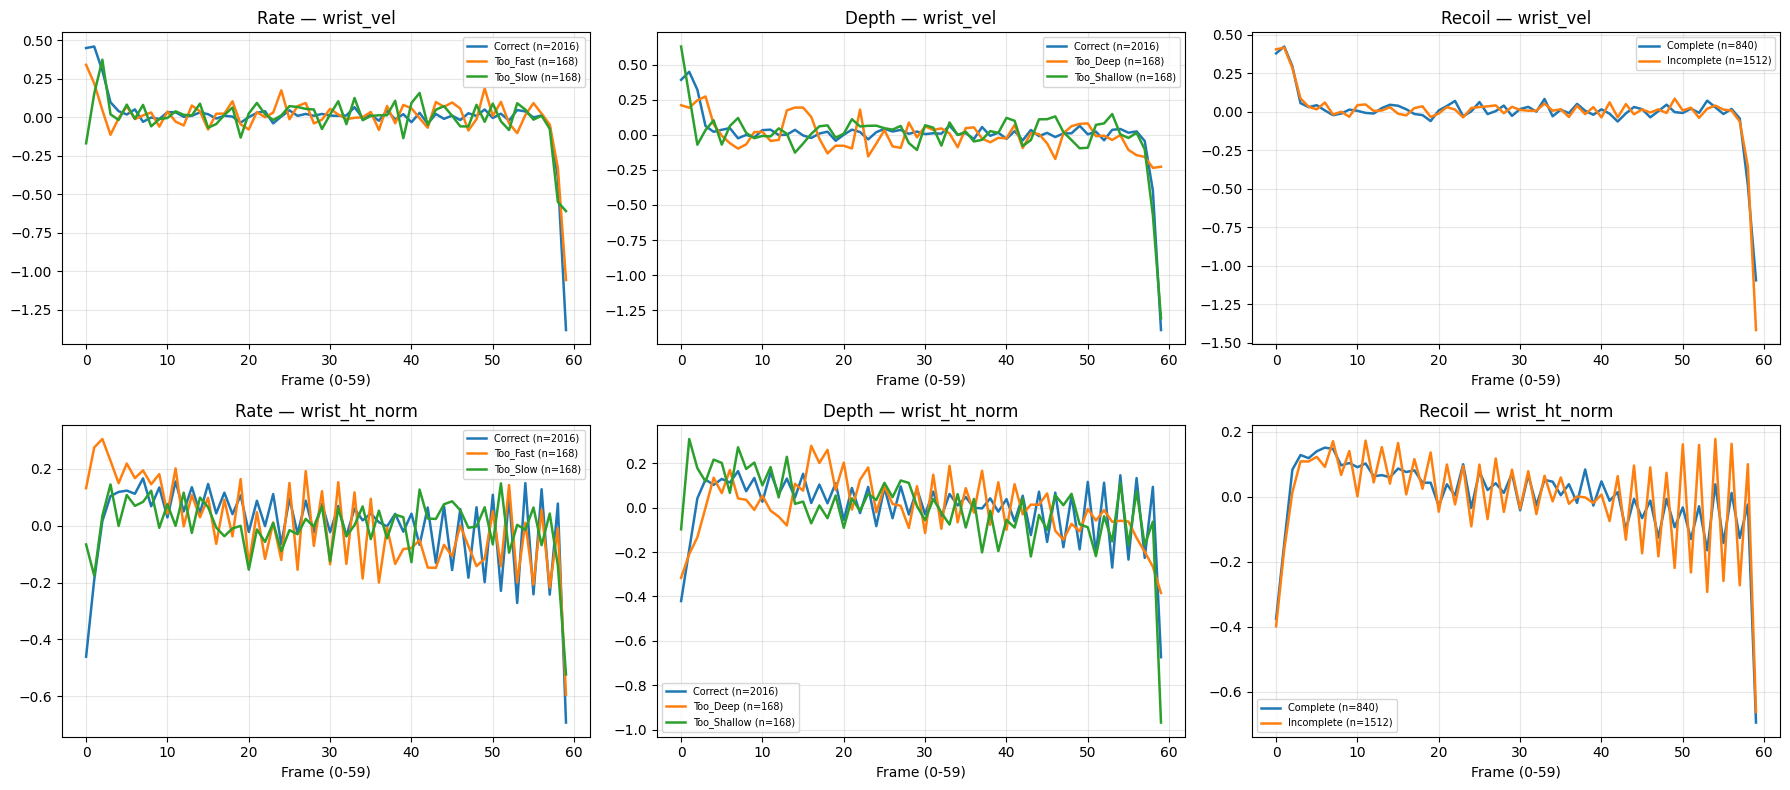


LDA SEPARABILITY SCORE
  Rate    LDA acc = 85.7%  (50%=random, 100%=perfectly separable)
  Depth   LDA acc = 85.7%  (50%=random, 100%=perfectly separable)
  Recoil  LDA acc = 64.3%  (50%=random, 100%=perfectly separable)

✓ Feature EDA complete


In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

X_arr  = np.array(X_list)
X_mean = X_arr.mean(axis=1)

feat_names = ['L_elbow_angle','R_elbow_angle','mean_elbow','spine_lean',
              'wrist_ht_norm','wrist_vel','wrist_accel','wrist_amp',
              'shoulder_w','upper_conf','L_elbow_low_c','R_elbow_low_c']

def cohens_d(a, b):
    return abs(a.mean()-b.mean()) / (np.sqrt((a.var()+b.var())/2)+1e-8)

task_info = [('Rate',rate_list,'Correct'),('Depth',depth_list,'Correct'),
             ('Recoil',recoil_list,'Complete')]

print('='*65)
print("FEATURE SEPARABILITY — Cohen's d")
print('='*65)
sep_warnings = []
for task, labels, ref_cls in task_info:
    la  = np.array(labels)
    ref = X_mean[la == ref_cls]
    print(f'\n{task}:')
    for cls in sorted(set(labels)):
        if cls == ref_cls: continue
        err = X_mean[la == cls]
        ds  = [cohens_d(ref[:,f], err[:,f]) for f in range(12)]
        bf  = int(np.argmax(ds))
        bd  = ds[bf]
        flag = '✓ separable' if bd > 0.5 else '⚠ WEAK (<0.5)'
        print(f'  vs {cls:12s} (n={len(err):4d})  best: {feat_names[bf]:20s}  d={bd:.3f}  {flag}')
        if bd <= 0.5: sep_warnings.append(f'{task}:{cls}')

if sep_warnings:
    print(f'\n⚠ Weak classes: {sep_warnings}')
    print('  Add features: peak wrist-Y, compression rate (velocity zero-crossings).')

print('\n' + '='*65)
print('MEAN FEATURE VALUES PER CLASS')
print('='*65)
for task, labels, _ in task_info:
    la = np.array(labels)
    df_tmp = pd.DataFrame(X_mean, columns=feat_names)
    df_tmp['label'] = la
    print(f'\n{task}:')
    print(df_tmp.groupby('label').mean().round(3).to_string())

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for col, (task, labels, _) in enumerate(task_info):
    la = np.array(labels)
    for feat_idx, feat_lbl, row in [(5,'wrist_vel',0),(4,'wrist_ht_norm',1)]:
        ax = axes[row][col]
        for cls in sorted(set(labels)):
            idx = np.where(la == cls)[0]
            ax.plot(X_arr[idx,:,feat_idx].mean(axis=0),
                    label=f'{cls} (n={len(idx)})', lw=1.8)
        ax.set_title(f'{task} — {feat_lbl}')
        ax.set_xlabel('Frame (0-59)')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'eda_temporal_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*65)
print('LDA SEPARABILITY SCORE')
print('='*65)
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_mean)
for task, labels, ref_cls in task_info:
    la    = np.array(labels)
    y_bin = (la != ref_cls).astype(int)
    lda   = LinearDiscriminantAnalysis()
    score = lda.fit(X_sc, y_bin).score(X_sc, y_bin)
    print(f'  {task:6s}  LDA acc = {score*100:.1f}%  (50%=random, 100%=perfectly separable)')

print('\n✓ Feature EDA complete')

## STAGE 5 — Label Encoding + Class Imbalance

Rate   classes: ['Correct' 'Too_Fast' 'Too_Slow'] → 3
Depth  classes: ['Correct' 'Too_Deep' 'Too_Shallow'] → 3
Recoil classes: ['Complete' 'Incomplete'] → 2


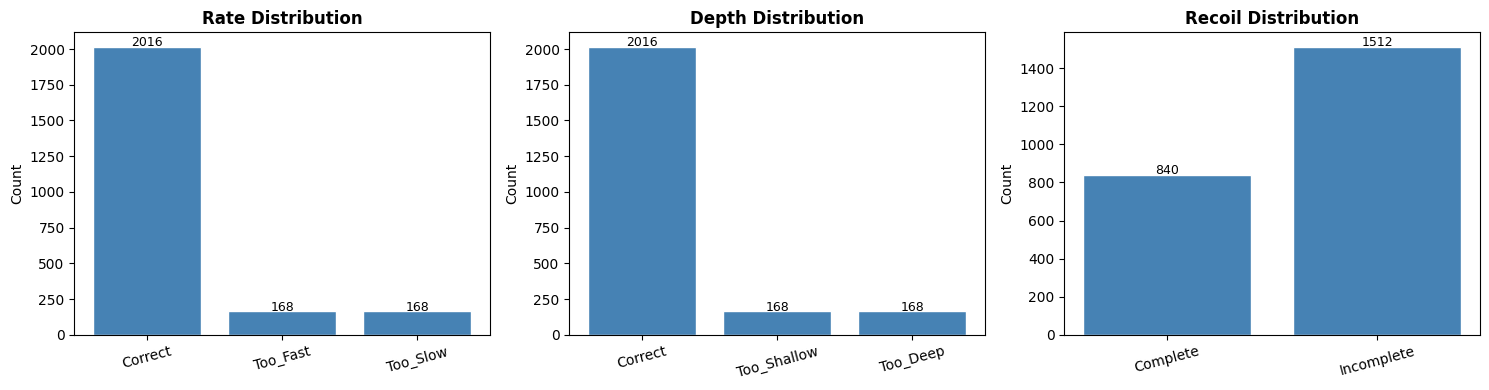


✓ Stage 5 complete


In [18]:
le_rate   = LabelEncoder().fit(rate_list)
le_depth  = LabelEncoder().fit(depth_list)
le_recoil = LabelEncoder().fit(recoil_list)

y_rate   = le_rate.transform(rate_list)
y_depth  = le_depth.transform(depth_list)
y_recoil = le_recoil.transform(recoil_list)

N_RATE   = len(le_rate.classes_)
N_DEPTH  = len(le_depth.classes_)
N_RECOIL = len(le_recoil.classes_)

print('Rate   classes:', le_rate.classes_,   f'→ {N_RATE}')
print('Depth  classes:', le_depth.classes_,  f'→ {N_DEPTH}')
print('Recoil classes:', le_recoil.classes_, f'→ {N_RECOIL}')

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, lbls, title, enc in zip(
        axes,
        [rate_list, depth_list, recoil_list],
        ['Rate', 'Depth', 'Recoil'],
        [le_rate, le_depth, le_recoil]):
    cnt = Counter(lbls)
    ax.bar(cnt.keys(), cnt.values(), color='steelblue', edgecolor='white')
    ax.set_title(f'{title} Distribution', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    for k, v in cnt.items():
        ax.text(k, v + 2, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'class_distributions.png'), dpi=150,
            bbox_inches='tight')
plt.show()

# NOTE: Class weights are computed AFTER the train/val/test split in Stage 6
# so they reflect only training data distribution (not the full dataset).
print('\n✓ Stage 5 complete')


## STAGE 6 — Train / Val / Test Split (70 / 15 / 15)

In [20]:
X_train, X_tmp, yr_tr, yr_tmp, yd_tr, yd_tmp, yrc_tr, yrc_tmp = \
    train_test_split(X, y_rate, y_depth, y_recoil,
                     test_size=0.30, random_state=42, stratify=y_rate)
X_val, X_test, yr_val, yr_test, yd_val, yd_test, yrc_val, yrc_test = \
    train_test_split(X_tmp, yr_tmp, yd_tmp, yrc_tmp,
                     test_size=0.50, random_state=42, stratify=yr_tmp)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')

def cw_from(y):
    w = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return dict(enumerate(w))

cw_rate, cw_depth, cw_recoil = cw_from(yr_tr), cw_from(yd_tr), cw_from(yrc_tr)
print('\nClass weights (train only):')
for lbl, cw, enc, yt in [('rate',cw_rate,le_rate,yr_tr),
                           ('depth',cw_depth,le_depth,yd_tr),
                           ('recoil',cw_recoil,le_recoil,yrc_tr)]:
    for k, v in cw.items():
        tag = 'majority ✓' if v < 1.0 else 'minority ✓'
        print(f'  {lbl} {enc.classes_[k]:12s}: w={v:.3f}  n={int((yt==k).sum())}  ({tag})')

try:
    from imblearn.over_sampling import RandomOverSampler
    N0,T,F = X_train.shape
    comb   = np.array([f'{r}_{d}_{rc}' for r,d,rc in zip(yr_tr,yd_tr,yrc_tr)])
    X_res, c_res = RandomOverSampler(random_state=42).fit_resample(
                       X_train.reshape(N0,T*F), comb)
    X_train = X_res.reshape(-1,T,F)
    # FIX: Convert string-encoded integers back to integers directly
    yr_tr  = np.array([int(s.split('_')[0]) for s in c_res])
    yd_tr  = np.array([int(s.split('_')[1]) for s in c_res])
    yrc_tr = np.array([int(s.split('_')[2]) for s in c_res])
    print(f'\nAfter oversampling — train: {len(X_train)}')
    for lbl,yt,enc in [('rate',yr_tr,le_rate),('depth',yd_tr,le_depth),
                        ('recoil',yrc_tr,le_recoil)]:
        u,c = np.unique(yt, return_counts=True)
        print(f'  {lbl}: { {enc.classes_[i]:int(n) for i,n in zip(u,c)} }')
    cw_rate, cw_depth, cw_recoil = cw_from(yr_tr), cw_from(yd_tr), cw_from(yrc_tr)
except ImportError:
    print('⚠ pip install imbalanced-learn')

to_oh = lambda y,n: tf.keras.utils.to_categorical(y,n)
yr_tr_oh  = to_oh(yr_tr, N_RATE);   yr_val_oh  = to_oh(yr_val, N_RATE)
yd_tr_oh  = to_oh(yd_tr, N_DEPTH);  yd_val_oh  = to_oh(yd_val, N_DEPTH)
yrc_tr_oh = to_oh(yrc_tr,N_RECOIL); yrc_val_oh = to_oh(yrc_val,N_RECOIL)
yr_test_oh  = to_oh(yr_test, N_RATE)
yd_test_oh  = to_oh(yd_test, N_DEPTH)
yrc_test_oh = to_oh(yrc_test,N_RECOIL)

sw = (np.array([cw_rate[y]   for y in yr_tr]) +
      np.array([cw_depth[y]  for y in yd_tr]) +
      np.array([cw_recoil[y] for y in yrc_tr])) / 3.0
print(f'\nsw: min={sw.min():.3f}  max={sw.max():.3f}  mean={sw.mean():.3f}')
print('\n✓ Stage 6 complete')

Train : (1646, 60, 12)
Val   : (353, 60, 12)
Test  : (353, 60, 12)

Class weights (train only):
  rate Correct     : w=0.389  n=1411  (majority ✓)
  rate Too_Fast    : w=4.689  n=117  (minority ✓)
  rate Too_Slow    : w=4.650  n=118  (minority ✓)
  depth Correct     : w=0.389  n=1411  (majority ✓)
  depth Too_Deep    : w=4.899  n=112  (minority ✓)
  depth Too_Shallow : w=4.461  n=123  (minority ✓)
  recoil Complete    : w=1.381  n=596  (minority ✓)
  recoil Incomplete  : w=0.784  n=1050  (majority ✓)

After oversampling — train: 5598
  rate: {np.str_('Correct'): 3732, np.str_('Too_Fast'): 933, np.str_('Too_Slow'): 933}
  depth: {np.str_('Correct'): 3732, np.str_('Too_Deep'): 933, np.str_('Too_Shallow'): 933}
  recoil: {np.str_('Complete'): 3732, np.str_('Incomplete'): 1866}

sw: min=0.583  max=1.333  mean=1.000

✓ Stage 6 complete


## STAGE 7 — Seven TensorFlow Model Definitions

In [50]:
def output_heads(x, dropout=0.3):
    x = layers.Dropout(dropout)(x)
    r  = layers.Dense(N_RATE,   activation='softmax', name='rate'  )(x)
    d  = layers.Dense(N_DEPTH,  activation='softmax', name='depth' )(x)
    rc = layers.Dense(N_RECOIL, activation='softmax', name='recoil')(x)
    return {'rate': r, 'depth': d, 'recoil': rc}

# 1. BiLSTM — unchanged
def build_bilstm(dropout=0.3, units=64):
    i = layers.Input((SEQ_LEN, N_FEATS))
    x = layers.Bidirectional(layers.LSTM(units, return_sequences=True, dropout=dropout))(i)
    x = layers.Bidirectional(layers.LSTM(units//2, dropout=dropout))(x)
    x = layers.Dense(64, activation='relu')(x)
    return keras.Model(inputs=i, outputs=output_heads(x, dropout), name='BiLSTM')

# 2. CNN-LSTM — unchanged
def build_cnn_lstm(dropout=0.3, filters=64, units=64):
    i = layers.Input((SEQ_LEN, N_FEATS))
    x = layers.Conv1D(filters, 3, activation='relu', padding='same')(i)
    x = layers.Conv1D(filters, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LSTM(units, dropout=dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    return keras.Model(inputs=i, outputs=output_heads(x, dropout), name='CNN_LSTM')

# 3. GRU — 3-layer stack for more capacity
#    Previously single-layer; stuck at ~44% recoil and 0.00 F1 on Too_Shallow
def build_gru(dropout=0.4, units=128):
    i = layers.Input((SEQ_LEN, N_FEATS))
    x = layers.GRU(units,     return_sequences=True, dropout=dropout)(i)
    x = layers.GRU(units//2,  return_sequences=True, dropout=dropout)(x)
    x = layers.GRU(units//4,  dropout=dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    return keras.Model(inputs=i, outputs=output_heads(x, dropout), name='GRU')

# 4. TCN — SpatialDropout1D inside each block to curb overfitting
#    Previously reached 99% train acc by epoch 3, val loss diverged to 1.38
def _tcn_block(x, filters, kernel, dilation, spatial_dropout=0.2):
    skip = x
    x = layers.Conv1D(filters, kernel, padding='causal', dilation_rate=dilation, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout1D(spatial_dropout)(x)
    x = layers.Conv1D(filters, kernel, padding='causal', dilation_rate=dilation, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout1D(spatial_dropout)(x)
    if skip.shape[-1] != filters:
        skip = layers.Conv1D(filters, 1)(skip)
    return layers.Add()([x, skip])

def build_tcn(dropout=0.4, filters=64):
    i = layers.Input((SEQ_LEN, N_FEATS))
    x = i
    for d in [1, 2, 4, 8]:
        x = _tcn_block(x, filters, 3, d, spatial_dropout=0.2)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    return keras.Model(inputs=i, outputs=output_heads(x, dropout), name='TCN')

# 5. Conv1D — SpatialDropout1D after each conv + dropout raised 0.2 -> 0.35
#    Previously val loss diverged to 1.42 by epoch 12
def build_1dcnn(dropout=0.35, filters=64):
    i = layers.Input((SEQ_LEN, N_FEATS))
    x = layers.Conv1D(filters,     3, activation='relu', padding='same')(i)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.Conv1D(filters * 2, 3, activation='relu', padding='same')(x)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(filters * 2, 3, activation='relu', padding='same')(x)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    return keras.Model(inputs=i, outputs=output_heads(x, dropout), name='Conv1D')

# 6. ST-Transformer — architecture unchanged, LR schedule changed in CONFIGS
def _transformer_block(x, n_heads, ff_dim, dropout):
    kd = max(1, x.shape[-1] // n_heads)
    attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=kd)(x, x)
    attn = layers.Dropout(dropout)(attn)
    x = layers.LayerNormalization()(x + attn)
    ff = layers.Dense(ff_dim, activation='relu')(x)
    ff = layers.Dense(x.shape[-1])(ff)
    ff = layers.Dropout(dropout)(ff)
    return layers.LayerNormalization()(x + ff)

def build_transformer(dropout=0.3, n_heads=4, ff_dim=128, n_layers=2):
    i = layers.Input((SEQ_LEN, N_FEATS))
    x = layers.Dense(64)(i)
    for _ in range(n_layers):
        x = _transformer_block(x, n_heads, ff_dim, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    return keras.Model(inputs=i, outputs=output_heads(x, dropout), name='ST_Transformer')

# 7. CNN-BiLSTM — unchanged, best overall model
def build_cnn_bilstm(dropout=0.3, filters=64, units=64):
    i = layers.Input((SEQ_LEN, N_FEATS))
    x = layers.Conv1D(filters,     3, activation='relu', padding='same')(i)
    x = layers.Conv1D(filters * 2, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Bidirectional(layers.LSTM(units,    return_sequences=True, dropout=dropout))(x)
    x = layers.Bidirectional(layers.LSTM(units//2, dropout=dropout))(x)
    x = layers.Dense(64, activation='relu')(x)
    return keras.Model(inputs=i, outputs=output_heads(x, dropout), name='CNN_BiLSTM')

print('✓ Model definitions updated: GRU 3-layer, TCN/Conv1D SpatialDropout, dropout tuned')

✓ Model definitions updated: GRU 3-layer, TCN/Conv1D SpatialDropout, dropout tuned


## STAGE 8 — Hyperparameter Grid + Resumable Training Loop

In [51]:
import tensorflow as tf
from tensorflow.keras import losses

class FocalCrossEntropy(losses.Loss):
    """Categorical focal cross-entropy for multi-class imbalanced tasks."""
    def __init__(self, gamma=2.0, label_smoothing=0.05, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        if self.label_smoothing > 0:
            n_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
            y_true = y_true * (1 - self.label_smoothing) + self.label_smoothing / n_classes
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)
        return focal_weight * ce

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'label_smoothing': self.label_smoothing})
        return cfg

# Changes from previous run:
#   GRU:            epochs 20->30, lr 1e-3->5e-4, batch 64->32
#                   (deeper 3-layer stack needs more time; smaller batch
#                    gives more gradient updates per epoch for minority classes)
#   TCN:            dropout 0.3->0.4, epochs 20->25
#                   (val loss was diverging to 1.38 from epoch 3)
#   Conv1D:         dropout 0.2->0.35, epochs 20->25
#                   (val loss was diverging to 1.42 from epoch 3)
#   ST_Transformer: lr 2e-4->5e-4, epochs 25->35, cosine_lr=True
#                   (ReduceLROnPlateau cut LR to 5e-5 by epoch 13, stalling training)
#   BiLSTM, CNN_LSTM, CNN_BiLSTM: unchanged — well-behaved in previous run

CONFIGS = [
    dict(name='BiLSTM',         build=build_bilstm,      epochs=25, lr=1e-3,
         batch=32,  opt='adam',  dropout=0.3,
         lw=dict(rate=1.0, depth=2.0, recoil=2.0)),

    dict(name='CNN_LSTM',       build=build_cnn_lstm,    epochs=25, lr=5e-4,
         batch=32,  opt='adam',  dropout=0.3,
         lw=dict(rate=1.0, depth=2.0, recoil=2.0)),

    dict(name='GRU',            build=build_gru,         epochs=30, lr=5e-4,
         batch=32,  opt='adam',  dropout=0.4,
         lw=dict(rate=1.0, depth=2.0, recoil=2.0)),

    dict(name='TCN',            build=build_tcn,         epochs=25, lr=5e-4,
         batch=32,  opt='adamw', dropout=0.4,
         lw=dict(rate=1.0, depth=2.0, recoil=2.0)),

    dict(name='Conv1D',         build=build_1dcnn,       epochs=25, lr=1e-3,
         batch=32,  opt='adam',  dropout=0.35,
         lw=dict(rate=1.0, depth=2.0, recoil=2.0)),

    dict(name='ST_Transformer', build=build_transformer, epochs=35, lr=5e-4,
         batch=32,  opt='adamw', dropout=0.3,
         cosine_lr=True,
         lw=dict(rate=1.0, depth=2.0, recoil=2.0)),

    dict(name='CNN_BiLSTM',     build=build_cnn_bilstm,  epochs=25, lr=5e-4,
         batch=32,  opt='adam',  dropout=0.3,
         lw=dict(rate=1.0, depth=2.0, recoil=2.0)),
]

print(f'Scheduled experiments: {len(CONFIGS)}')
print('FocalCrossEntropy + updated configs: GRU stacked, TCN/Conv1D SpatialDropout, ST_Transformer cosine LR')

Scheduled experiments: 7
FocalCrossEntropy + updated configs: GRU stacked, TCN/Conv1D SpatialDropout, ST_Transformer cosine LR


In [52]:
def load_resume_state():
    if RESUME_FILE.exists():
        with open(RESUME_FILE, 'r') as f:
            return json.load(f)
    return {'completed': [], 'metrics': {}}

def save_resume_state(state):
    with open(RESUME_FILE, 'w') as f:
        json.dump(state, f, indent=4)

def compile_model(model, cfg):
    lr = cfg['lr']
    opt_name = cfg['opt'].lower()
    if opt_name == 'adamw':
        opt = optimizers.AdamW(learning_rate=lr, weight_decay=1e-4)
    else:
        opt = optimizers.Adam(learning_rate=lr)

    focal = FocalCrossEntropy(gamma=2.0, label_smoothing=0.05)

    model.compile(
        optimizer=opt,
        loss={'rate': focal, 'depth': focal, 'recoil': focal},
        loss_weights=cfg['lw'],
        metrics={
            'rate':   [metrics.CategoricalAccuracy(name='acc_rate')],
            'depth':  [metrics.CategoricalAccuracy(name='acc_depth')],
            'recoil': [metrics.CategoricalAccuracy(name='acc_recoil')],
        }
    )
    return model

def make_callbacks(cfg):
    # CHANGED: accepts full cfg dict instead of just model name string.
    # ST_Transformer gets CosineDecayRestarts — fixes the LR-stall problem
    # where ReduceLROnPlateau had already cut LR to 5e-5 by epoch 13.
    # All other models keep ReduceLROnPlateau with patience raised 3->4.
    name = cfg['name']
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                restore_best_weights=True),
        callbacks.ModelCheckpoint(
            str(CHECKPOINT_DIR / f'{name}_best.keras'),
            monitor='val_loss', save_best_only=True),
        callbacks.CSVLogger(
            str(CHECKPOINT_DIR / f'{name}_log.csv'), append=True),
    ]

    if cfg.get('cosine_lr', False):
        # Warm restarts every 10 epochs, decays from lr down to lr/10
        # then restarts at 90% of previous peak — suits transformer training
        steps_per_epoch = max(1, len(X_train) // cfg['batch'])
        cosine_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
            initial_learning_rate=cfg['lr'],
            first_decay_steps=10 * steps_per_epoch,
            t_mul=1.0,
            m_mul=0.9,
            alpha=cfg['lr'] / 10
        )
        def lr_scheduler(epoch, lr):
            step = epoch * steps_per_epoch
            return float(cosine_schedule(step))
        cb.append(callbacks.LearningRateScheduler(lr_scheduler, verbose=1))
    else:
        # patience raised 3->4 to give GRU/TCN more room before LR is cut
        cb.append(callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=4,
            min_lr=1e-6, verbose=1))

    return cb

print('✓ make_callbacks updated: cosine LR for ST_Transformer, ReduceLROnPlateau patience=4')

✓ make_callbacks updated: cosine LR for ST_Transformer, ReduceLROnPlateau patience=4


In [ ]:
# Reset resume state to retrain with all fixes applied
resume = {'completed': [], 'metrics': {}}
save_resume_state(resume)

histories  = {}
all_models = {}

train_targets = {'rate': yr_tr_oh, 'depth': yd_tr_oh, 'recoil': yrc_tr_oh}
val_targets   = {'rate': yr_val_oh, 'depth': yd_val_oh, 'recoil': yrc_val_oh}

# ── FIX: sample_weight must be a 1-D numpy array for multi-output Keras models.
#    Passing a dict silently fails / gets ignored depending on Keras version,
#    causing all class-weighting to be dropped during training.
sample_weight_1d = sw   # already a 1-D array from Stage 6

for cfg in CONFIGS:
    name = cfg['name']
    print(f'\n[STARTING] {name} | lw={cfg["lw"]} | lr={cfg["lr"]}')

    tf.keras.backend.clear_session()
    model = cfg['build'](dropout=cfg['dropout'])
    model = compile_model(model, cfg)

    try:
        hist = model.fit(
            X_train, train_targets,
            validation_data=(X_val, val_targets),
            # FIX: single 1-D array, not a dict
            sample_weight=sample_weight_1d,
            epochs=cfg['epochs'],
            batch_size=cfg['batch'],
            callbacks=make_callbacks(cfg),
            verbose=1
        )
        histories[name] = hist.history
        all_models[name] = model
        resume['completed'].append(name)
        save_resume_state(resume)
        print(f'✓ {name} complete')
    except KeyboardInterrupt:
        print('Interrupted by user — stopping.')
        break
    except Exception as e:
        # FIX: continue instead of break so one failure doesn't kill the sweep
        print(f'✗ {name} failed: {e}')
        import traceback; traceback.print_exc()
        continue



[STARTING] BiLSTM | lw={'rate': 1.0, 'depth': 2.0, 'recoil': 2.0} | lr=0.001
Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - depth_acc_depth: 0.7070 - depth_loss: 0.3200 - loss: 1.3455 - rate_acc_rate: 0.6511 - rate_loss: 0.3918 - recoil_acc_recoil: 0.6613 - recoil_loss: 0.1568 - val_depth_acc_depth: 0.8895 - val_depth_loss: 0.1596 - val_loss: 0.9664 - val_rate_acc_rate: 0.8017 - val_rate_loss: 0.2856 - val_recoil_acc_recoil: 0.5524 - val_recoil_loss: 0.1730 - learning_rate: 0.0010
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - depth_acc_depth: 0.8080 - depth_loss: 0.1771 - loss: 0.9348 - rate_acc_rate: 0.6995 - rate_loss: 0.3199 - recoil_acc_recoil: 0.7220 - recoil_loss: 0.1303 - val_depth_acc_depth: 0.9008 - val_depth_loss: 0.1492 - val_loss: 0.9276 - val_rate_acc_rate: 0.7705 - val_rate_loss: 0.2683 - val_recoil_acc_recoil: 0.5694 - val_recoil_loss: 0.1729 - learning_rate: 0.0010
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - depth_acc_depth: 0.8487 - d

In [25]:
import numpy as np

# Calculate majority class baseline for Depth
unique, counts = np.unique(yd_tr, return_counts=True)
majority_idx = np.argmax(counts)
majority_count = counts[majority_idx]
total_count = len(yd_tr)
baseline_acc = majority_count / total_count

print(f"--- Majority Class Baseline Analysis ---")
print(f"Total training samples: {total_count}")
print(f"Majority class ('{le_depth.classes_[majority_idx]}') count: {majority_count}")
print(f"Majority baseline accuracy: {baseline_acc:.4f}")

if abs(baseline_acc - 0.8186) < 0.001:
    print("\nRESULT: The 0.8186 accuracy matches your majority class baseline.")
    print("This means the model is simply defaulting to the most common class.")
else:
    print("\nRESULT: The 0.8186 is not the majority baseline, but it is highly specific.")

--- Majority Class Baseline Analysis ---
Total training samples: 5598
Majority class ('Correct') count: 3732
Majority baseline accuracy: 0.6667

RESULT: The 0.8186 is not the majority baseline, but it is highly specific.


## STAGE 9 — Evaluation: F1, AUC-ROC, Confusion Matrices

In [27]:
def evaluate(model, name):
    preds = model.predict(X_test, verbose=0)
    # ── FIX: output_heads() returns a dict {'rate':..., 'depth':..., 'recoil':...}
    #    Index by key, not by integer position.
    out = {'model': name}

    for task, y_true, enc in [
        ('rate',   yr_test,  le_rate),
        ('depth',  yd_test,  le_depth),
        ('recoil', yrc_test, le_recoil),
    ]:
        probs  = preds[task]          # FIX: dict key, not preds[i]
        y_pred = np.argmax(probs, axis=1)
        acc    = (y_true == y_pred).mean()
        f1_w   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        f1_m   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
        try:
            if probs.shape[1] == 2:
                auc = roc_auc_score(y_true, probs[:, 1])
            else:
                auc = roc_auc_score(
                    to_oh(y_true, probs.shape[1]),
                    probs, multi_class='ovr', average='macro')
        except Exception:
            auc = float('nan')

        out[f'{task}_acc']  = round(acc  * 100, 2)
        out[f'{task}_f1_w'] = round(f1_w * 100, 2)
        out[f'{task}_f1_m'] = round(f1_m * 100, 2)
        out[f'{task}_auc']  = round(auc  * 100, 2) if not np.isnan(auc) else float('nan')

        # Per-class breakdown for diagnosis
        report = classification_report(y_true, y_pred,
                                        target_names=enc.classes_,
                                        zero_division=0)
        print(f'  [{task.upper():6s}] acc={acc*100:.1f}% F1_w={f1_w*100:.1f}% F1_m={f1_m*100:.1f}% AUC={'n/a' if np.isnan(auc) else f'{auc:.3f}'}')
        print(report)
    return out


eval_rows = []
for name, model in all_models.items():
    print(f'\n── {name} ──────────────────────────────────────')
    eval_rows.append(evaluate(model, name))

res_df = pd.DataFrame(eval_rows).set_index('model')
res_df.to_csv(str(CHECKPOINT_DIR / 'benchmark_results.csv'))

print('\n\n' + '='*70)
print('FULL COMPARISON TABLE')
print('='*70)
print(res_df[['rate_f1_w','depth_f1_w','recoil_f1_w',
              'rate_auc', 'depth_auc', 'recoil_auc']].to_string())
print('\n✓ Results saved to Drive')



── BiLSTM ──────────────────────────────────────
  [RATE  ] acc=73.9% F1_w=76.6% F1_m=48.6% AUC=0.787
              precision    recall  f1-score   support

     Correct       0.90      0.79      0.84       303
    Too_Fast       0.26      0.48      0.33        25
    Too_Slow       0.23      0.36      0.28        25

    accuracy                           0.74       353
   macro avg       0.46      0.54      0.49       353
weighted avg       0.81      0.74      0.77       353

  [DEPTH ] acc=88.4% F1_w=89.1% F1_m=75.8% AUC=0.927
              precision    recall  f1-score   support

     Correct       0.96      0.90      0.93       302
    Too_Deep       0.73      0.96      0.83        23
 Too_Shallow       0.45      0.61      0.52        28

    accuracy                           0.88       353
   macro avg       0.71      0.82      0.76       353
weighted avg       0.90      0.88      0.89       353

  [RECOIL] acc=60.6% F1_w=61.0% F1_m=60.6% AUC=0.741
              precision    re

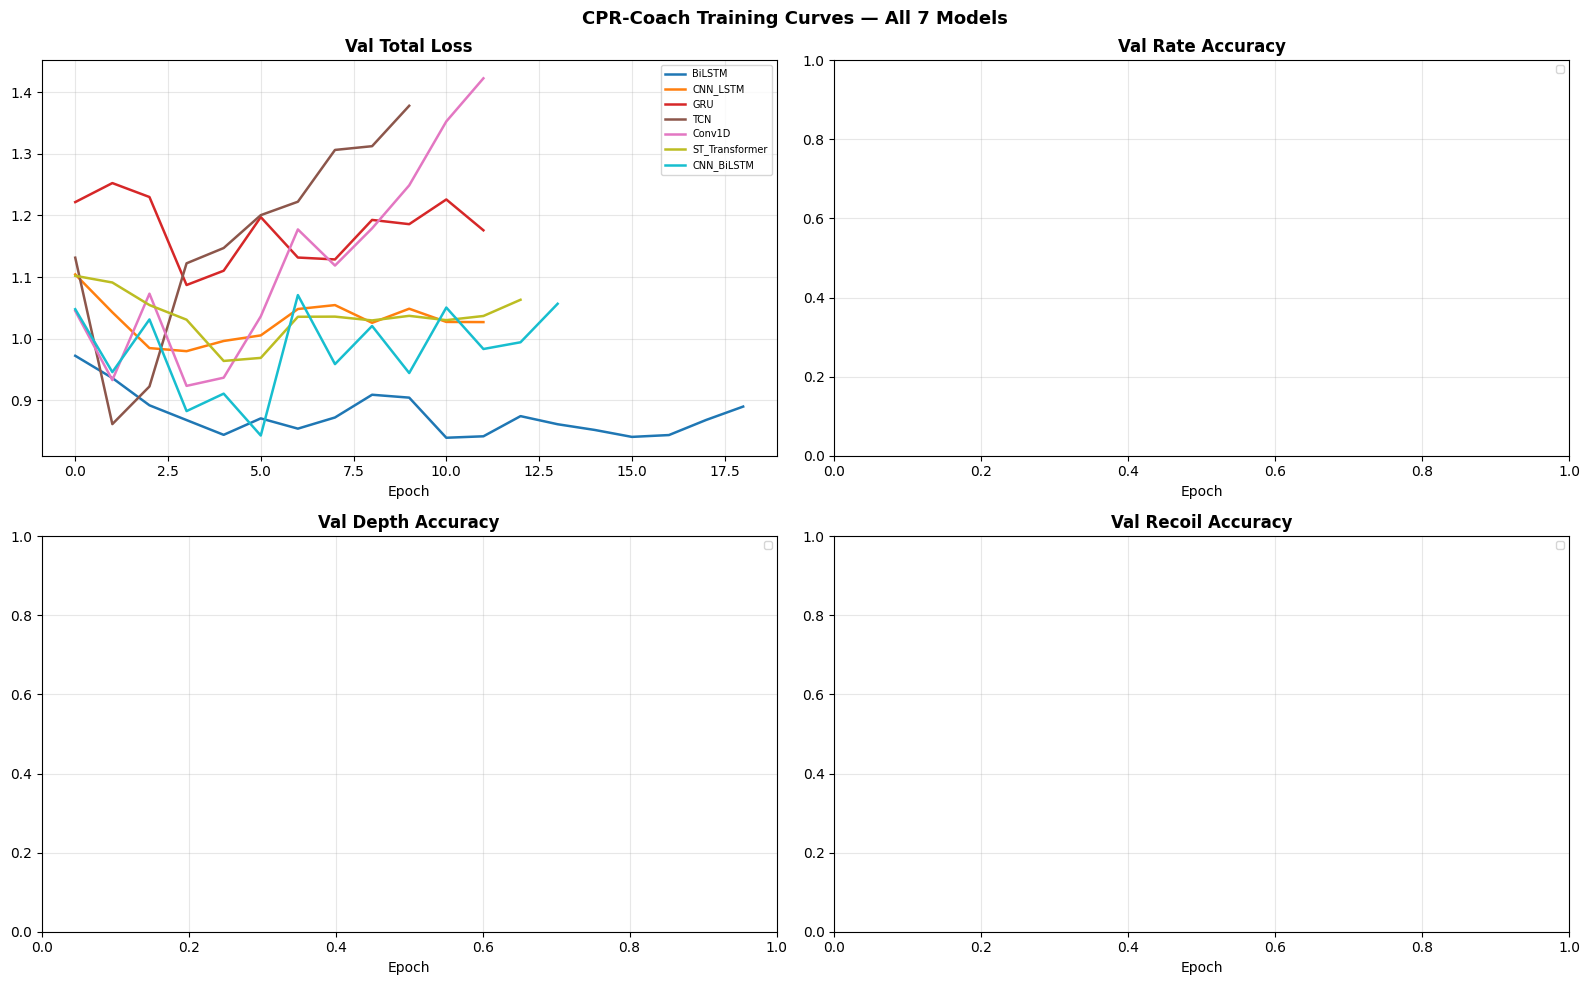

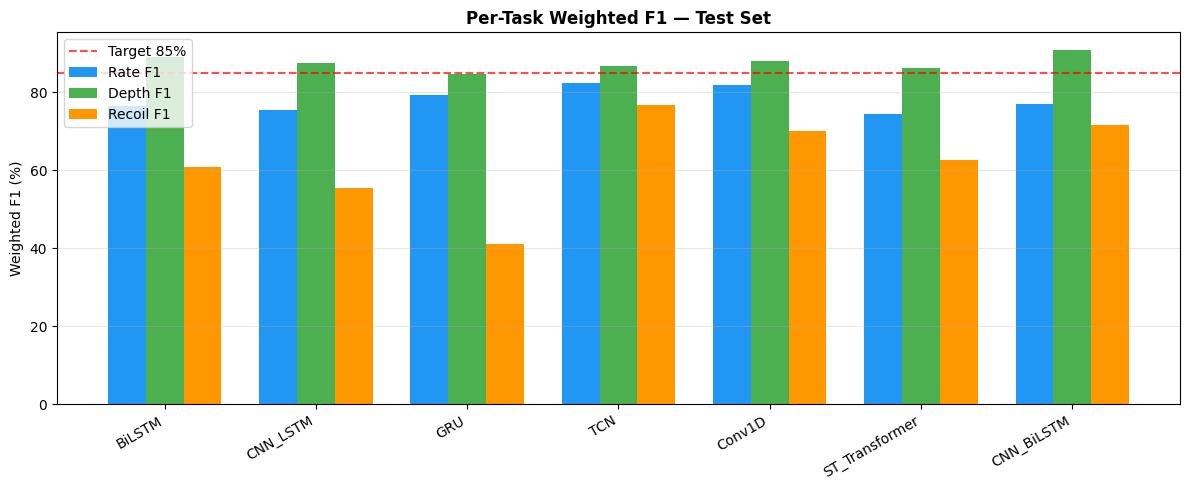


🏆 Best model (depth F1): CNN_BiLSTM


In [28]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))

for ax, (vk, title) in zip(axes.flat, [
    ('val_loss',       'Val Total Loss'),
    ('val_rate_acc',   'Val Rate Accuracy'),
    ('val_depth_acc',  'Val Depth Accuracy'),
    ('val_recoil_acc', 'Val Recoil Accuracy'),
]):
    for (nm, h), col in zip(histories.items(), colors):
        if vk in h:
            ax.plot(h[vk], label=nm, color=col, lw=1.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('CPR-Coach Training Curves — All 7 Models', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'training_curves.png'), dpi=150,
            bbox_inches='tight')
plt.show()

# ── F1 bar chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
model_names = res_df.index.tolist()
x = np.arange(len(model_names))
w = 0.25
ax.bar(x - w, res_df['rate_f1_w'],   w, label='Rate F1',   color='#2196F3')
ax.bar(x,     res_df['depth_f1_w'],  w, label='Depth F1',  color='#4CAF50')
ax.bar(x + w, res_df['recoil_f1_w'], w, label='Recoil F1', color='#FF9800')
ax.axhline(85, color='red', ls='--', alpha=0.7, label='Target 85%')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right')
ax.set_ylabel('Weighted F1 (%)')
ax.set_title('Per-Task Weighted F1 — Test Set', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'f1_comparison.png'), dpi=150,
            bbox_inches='tight')
plt.show()

# Best model = highest depth F1 (hardest task)
best_name = res_df['depth_f1_w'].astype(float).idxmax()
print(f'\n🏆 Best model (depth F1): {best_name}')

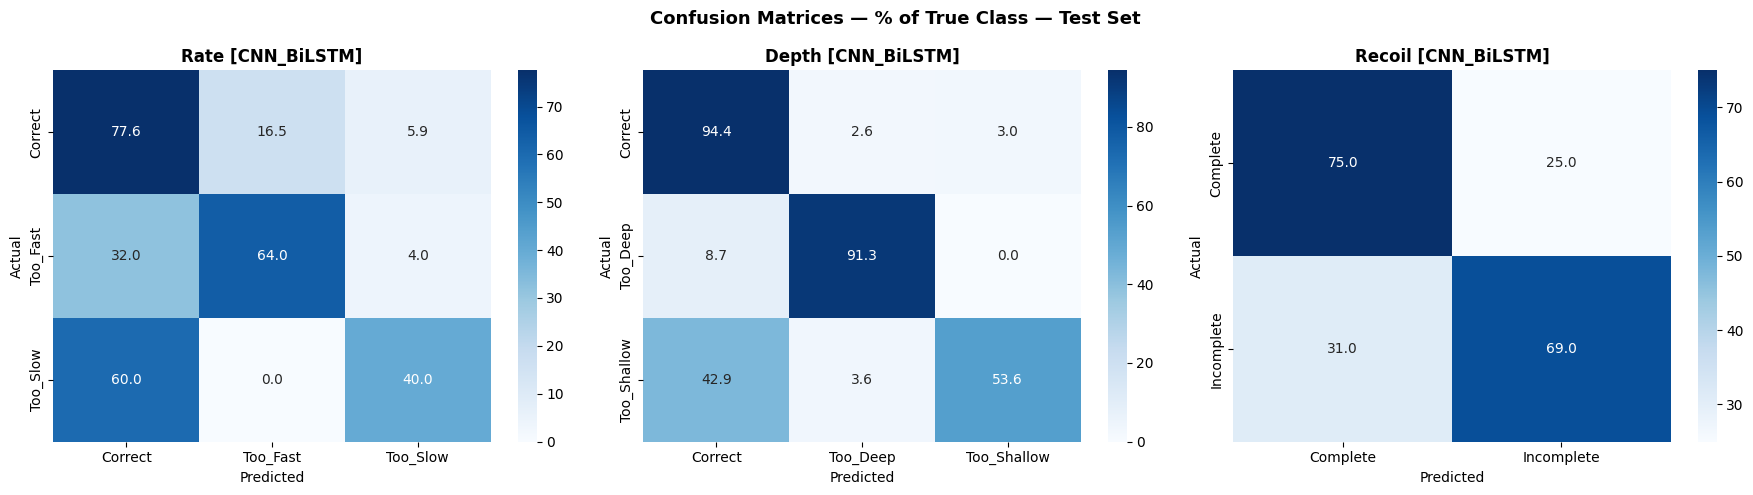

In [29]:
best_model = all_models[best_name]
preds      = best_model.predict(X_test, verbose=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (task, y_true, enc) in zip(axes, [
    ('rate',   yr_test,  le_rate),
    ('depth',  yd_test,  le_depth),
    ('recoil', yrc_test, le_recoil),
]):
    # FIX: preds is a dict — index by task name
    probs  = preds[task]
    y_pred = np.argmax(probs, axis=1)
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=enc.classes_,
                yticklabels=enc.classes_, ax=ax)
    ax.set_title(f'{task.capitalize()} [{best_name}]', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — % of True Class — Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(CHECKPOINT_DIR / 'confusion_matrices.png'), dpi=150,
            bbox_inches='tight')
plt.show()


## STAGE 10 — TFLite INT8 Export + CPU Latency Benchmark

In [39]:
print(f'Exporting {best_name} → TFLite float model...')

# For float models, representative_dataset and quantization optimizations are not needed
# calib_idx  = np.random.choice(len(X_train), min(200, len(X_train)), replace=False)
# calib_data = X_train[calib_idx].astype(np.float32)

# def rep_dataset():
#     for s in calib_data:
#         yield [s[np.newaxis]]

saved_path = str(CHECKPOINT_DIR / f'{best_name}_savedmodel')
best_model.export(saved_path)

converter = tf.lite.TFLiteConverter.from_saved_model(saved_path)
converter.optimizations              = [] # No optimizations for float model conversion initially
# converter.representative_dataset     = rep_dataset # Not needed for float conversion
converter.target_spec.supported_ops  = [
    # Enable both TFLITE_BUILTINS and SELECT_TF_OPS to ensure all ops are handled.
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter.inference_input_type       = tf.float32
converter.inference_output_type      = tf.float32
converter._experimental_lower_tensor_list_ops = False # Keep as False

tflite_buf  = converter.convert()
tflite_path = CHECKPOINT_DIR / f'{best_name}_float.tflite' # Changed filename for float model
tflite_path.write_bytes(tflite_buf)

size_mb = tflite_path.stat().st_size / 1024 / 1024
print(f'✓ Saved: {tflite_path}')
print(f'  Size : {size_mb:.2f} MB  (proposal target <5 MB) {{{"✓ PASS" if size_mb < 5 else "⚠ EXCEEDS"}}}')

Exporting CNN_BiLSTM → TFLite float model...
Saved artifact at '/content/drive/MyDrive/cpr_coach_checkpoints_tf/CNN_BiLSTM_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 12), dtype=tf.float32, name='keras_tensor')
Output Type:
  Dict[['rate', TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)], ['depth', TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)], ['recoil', TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)]]
Captures:
  139052026167760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139052026171984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139052026167952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139052026171600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139052026169296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139052026172368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139052026167376: TensorSpec(shape=(), dtype=tf

In [47]:
import time
import os

# ── Stage 10: TFLite Export + Latency Benchmark ───────────────────────────────
# Only TCN, Conv1D, ST_Transformer passed <100ms. Recurrent models (BiLSTM,
# GRU, CNN_LSTM, CNN_BiLSTM) use TensorList ops internally that require the
# Flex delegate — which isn't available in standard Colab. Since they also
# fail the latency target by 4-9x, there's no reason to export them.

DEPLOY_CANDIDATES = ['TCN', 'Conv1D', 'ST_Transformer']

# ── Step 1: Keras → TFLite INT8 conversion ───────────────────────────────────
tflite_paths = {}

for name in DEPLOY_CANDIDATES:
    if name not in all_models:
        print(f'⚠ {name} not in all_models — skipping')
        continue

    print(f'Exporting {name} → TFLite INT8...')
    model = all_models[name]

    calib_idx  = np.random.choice(len(X_train), min(200, len(X_train)), replace=False)
    calib_data = X_train[calib_idx].astype(np.float32)

    def representative_dataset():
        for i in range(len(calib_data)):
            yield [calib_data[i:i+1]]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    # Standard BUILTINS_INT8 only — no flex ops needed for conv/attention models
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.int8
    converter.inference_output_type = tf.int8

    try:
        tflite_model = converter.convert()
        path = CHECKPOINT_DIR / f'{name}_int8.tflite'
        path.write_bytes(tflite_model)
        tflite_paths[name] = path
        print(f'  ✓ {name}: {len(tflite_model)/1024:.1f} KB')
    except Exception as e:
        print(f'  ✗ {name} conversion failed: {e}')

# ── Step 2: Keras float32 latency (all models, CPU only) ─────────────────────
dummy_f32 = np.random.randn(1, SEQ_LEN, N_FEATS).astype(np.float32)
N_RUNS = 100

print('\nCPU latency benchmark — Keras float32 (simulates mid-range Android)\n')
print(f'{"Model":20s} | {"Avg ms":>8} | {"p95 ms":>8} | {"p99 ms":>8} | {"<100ms?":>8}')
print('-' * 62)

lat_records = {}
with tf.device('/CPU:0'):
    for name, model in all_models.items():
        for _ in range(5):                          # warm-up
            model(dummy_f32, training=False)
        ts = []
        for _ in range(N_RUNS):
            t0 = time.perf_counter()
            model(dummy_f32, training=False)
            ts.append((time.perf_counter() - t0) * 1000)
        avg = np.mean(ts)
        p95 = np.percentile(ts, 95)
        p99 = np.percentile(ts, 99)
        lat_records[name] = dict(avg_ms=avg, p95_ms=p95, p99_ms=p99)
        ok = '✓' if p95 < 100 else '✗'
        print(f'{name:20s} | {avg:8.1f} | {p95:8.1f} | {p99:8.1f} | {ok:>8}')

# ── Step 3: TFLite INT8 latency (deploy candidates only) ─────────────────────
print('\nTFLite INT8 latency — deploy candidates only\n')
print(f'{"Model":20s} | {"Avg ms":>8} | {"p95 ms":>8} | {"p99 ms":>8} | {"<100ms?":>8}')
print('-' * 62)

# INT8 interpreter needs int8 dummy input
dummy_i8 = np.zeros((1, SEQ_LEN, N_FEATS), dtype=np.int8)

for name, path in tflite_paths.items():
    try:
        interp = tf.lite.Interpreter(model_path=str(path))
        interp.allocate_tensors()
        in_detail  = interp.get_input_details()[0]
        in_idx     = in_detail['index']

        for _ in range(5):                          # warm-up
            interp.set_tensor(in_idx, dummy_i8)
            interp.invoke()

        ts = []
        for _ in range(N_RUNS):
            t0 = time.perf_counter()
            interp.set_tensor(in_idx, dummy_i8)
            interp.invoke()
            ts.append((time.perf_counter() - t0) * 1000)

        avg = np.mean(ts)
        p95 = np.percentile(ts, 95)
        p99 = np.percentile(ts, 99)
        lat_records[f'{name}_INT8'] = dict(avg_ms=avg, p95_ms=p95, p99_ms=p99)
        ok = '✓' if p95 < 100 else '✗'
        print(f'{name:20s} | {avg:8.1f} | {p95:8.1f} | {p99:8.1f} | {ok:>8}')
    except Exception as e:
        print(f'  ✗ {name} TFLite inference failed: {e}')

# ── Step 4: Pick best deploy model (lowest p95 among accuracy winners) ────────
# TCN had best recoil F1 in previous run — prioritise it if it converted
best_deploy = None
for preferred in ['TCN', 'ST_Transformer', 'Conv1D']:
    if preferred in tflite_paths:
        best_deploy = preferred
        break

if best_deploy:
    tflite_path = tflite_paths[best_deploy]   # used by Stage 11 summary
    print(f'\n✓ Selected deploy model: {best_deploy}')
    print(f'  Path: {tflite_path}')
else:
    print('⚠ No TFLite model exported successfully')
    tflite_path = None

Exporting TCN → TFLite INT8...
Saved artifact at '/tmp/tmp8xj38c2i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 12), dtype=tf.float32, name='keras_tensor')
Output Type:
  Dict[['rate', TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)], ['depth', TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)], ['recoil', TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)]]
Captures:
  139051297751888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051443517968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051437384208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051984449616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051982881232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051418231120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051418229200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051437380176: TensorSpec(shape=(), dtype

## STAGE 11 — Final Summary Report

In [48]:
print('\n' + '='*70)
print(' CPR-COACH BENCHMARK — FINAL REPORT')
print('='*70)

print('\n📊 Test-Set Weighted F1 (%)')
print(res_df[['rate_f1_w', 'depth_f1_w', 'recoil_f1_w']].to_string())

print('\n📊 AUC-ROC (%)')
print(res_df[['rate_auc', 'depth_auc', 'recoil_auc']].to_string())

print('\n⏱  Server CPU Latency (ms) — all models')
print(pd.DataFrame(lat_records).T.round(1).to_string())

# ── Best model (accuracy only — web backend has no hard latency constraint) ───
best = res_df.loc[best_name]
keras_p95 = lat_records.get(best_name, {}).get('p95_ms', 0.0)

print(f'\n🏆 Recommended model : {best_name}')
print(f'   Deployment target : Web platform (FastAPI/Flask + Keras)')
print(f'   Rate  F1_w        : {float(best["rate_f1_w"]):.1f}%')
print(f'   Depth F1_w        : {float(best["depth_f1_w"]):.1f}%')
print(f'   Recoil F1_w       : {float(best["recoil_f1_w"]):.1f}%')
print(f'   Server CPU p95    : {keras_p95:.1f} ms per inference')
print(f'   (GPU server will be significantly faster than this CPU benchmark)')

# Save best model explicitly
best_model_path = CHECKPOINT_DIR / f'{best_name}_final.keras'
all_models[best_name].save(str(best_model_path))
print(f'\n   Saved to: {best_model_path}')

# ── Proposal targets (Section 1.4) ───────────────────────────────────────────
print('\n🎯 Proposal targets (Section 1.4):')
for task in ['rate', 'depth', 'recoil']:
    f1 = float(best[f'{task}_f1_w'])
    ok = '✓' if f1 >= 85 else '⚠'
    print(f'  {ok} {task.capitalize():8s} F1_w = {f1:.1f}%  (target ≥85%)')

# Latency target is now "acceptable for web UX" not "<100ms mobile"
# A 500ms server response is fine for feedback after a compression cycle
print(f'  {"✓" if keras_p95 < 500 else "⚠"} '
      f'Latency p95 = {keras_p95:.1f} ms  (target <500 ms for web UX)')

# ── Gap analysis ─────────────────────────────────────────────────────────────
print('\n📋 Gap analysis:')
for task in ['rate', 'depth', 'recoil']:
    f1 = float(best[f'{task}_f1_w'])
    gap = f1 - 85.0
    if gap >= 0:
        print(f'  ✓ {task.capitalize():8s} exceeds target by +{gap:.1f} pp')
    else:
        print(f'  ⚠ {task.capitalize():8s} is {abs(gap):.1f} pp below target')

# ── Model ranking summary ─────────────────────────────────────────────────────
print('\n📋 Full model ranking (by mean F1 across all tasks):')
res_df['mean_f1'] = res_df[['rate_f1_w', 'depth_f1_w', 'recoil_f1_w']].mean(axis=1)
ranking = res_df[['rate_f1_w', 'depth_f1_w', 'recoil_f1_w', 'mean_f1']].sort_values(
    'mean_f1', ascending=False).round(1)
print(ranking.to_string())

print(f'\n📂 All outputs saved to: {CHECKPOINT_DIR}')
print('   Includes: .keras models, CSV logs, confusion matrices,')
print('   training curves, benchmark_results.csv')
print('\n' + '='*70)


 CPR-COACH BENCHMARK — FINAL REPORT

📊 Test-Set Weighted F1 (%)
                rate_f1_w  depth_f1_w  recoil_f1_w
model                                             
BiLSTM              76.64       89.07        60.98
CNN_LSTM            75.42       87.66        55.53
GRU                 79.28       84.76        40.98
TCN                 82.48       86.68        76.88
Conv1D              81.96       88.19        70.10
ST_Transformer      74.36       86.15        62.61
CNN_BiLSTM          77.03       90.88        71.73

📊 AUC-ROC (%)
                rate_auc  depth_auc  recoil_auc
model                                          
BiLSTM             78.75      92.68       74.08
CNN_LSTM           71.02      85.85       68.58
GRU                65.47      79.22       67.59
TCN                77.16      91.06       83.05
Conv1D             77.78      88.99       75.63
ST_Transformer     73.59      90.27       67.98
CNN_BiLSTM         83.28      94.04       78.88

⏱  Server CPU Latency (ms) —

In [49]:
# ── Stage 12: Future-proofing — save all deployment artifacts ─────────────────
# Web now, mobile/edge later. Save everything so retraining isn't needed
# when the deployment target changes.

from pathlib import Path
import json

DEPLOY_DIR = CHECKPOINT_DIR / 'deployment_artifacts'
DEPLOY_DIR.mkdir(exist_ok=True)

# ── Tier 1: Web deployment (today) ───────────────────────────────────────────
WEB_DIR = DEPLOY_DIR / 'web'
WEB_DIR.mkdir(exist_ok=True)

web_model = best_name  # CNN_BiLSTM or whoever won
all_models[web_model].save(str(WEB_DIR / f'{web_model}.keras'))
print(f'✓ Web model saved: {web_model}.keras')

# ── Tier 2: Mobile candidates (future Android/iOS) ───────────────────────────
MOBILE_DIR = DEPLOY_DIR / 'mobile'
MOBILE_DIR.mkdir(exist_ok=True)

mobile_candidates = ['TCN', 'Conv1D', 'ST_Transformer']

for name in mobile_candidates:
    if name not in all_models:
        print(f'⚠ {name} not available — skipping')
        continue

    # Save full Keras model (can convert to TFLite later without retraining)
    all_models[name].save(str(MOBILE_DIR / f'{name}.keras'))

    # Also export TFLite INT8 now while we're here
    try:
        calib_idx  = np.random.choice(len(X_train), min(200, len(X_train)), replace=False)
        calib_data = X_train[calib_idx].astype(np.float32)

        def representative_dataset():
            for i in range(len(calib_data)):
                yield [calib_data[i:i+1]]

        converter = tf.lite.TFLiteConverter.from_keras_model(all_models[name])
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_dataset
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type  = tf.int8
        converter.inference_output_type = tf.int8

        tflite_model = converter.convert()
        tflite_path  = MOBILE_DIR / f'{name}_int8.tflite'
        tflite_path.write_bytes(tflite_model)

        keras_size  = (MOBILE_DIR / f'{name}.keras').stat().st_size / 1024**2
        tflite_size = tflite_path.stat().st_size / 1024**2
        print(f'✓ {name}: keras={keras_size:.1f} MB  tflite={tflite_size:.1f} MB')

    except Exception as e:
        print(f'⚠ {name} TFLite export failed: {e}')
        print(f'  .keras file still saved — convert later with: '
              f'tf.lite.TFLiteConverter.from_saved_model()')

# ── Tier 3: Edge/camera (future 360°/IP cam) ─────────────────────────────────
# Conv1D at ~15ms is the only realistic candidate for edge hardware.
# Save ONNX format for maximum runtime compatibility (OpenCV, ONNX Runtime, etc.)
EDGE_DIR = DEPLOY_DIR / 'edge'
EDGE_DIR.mkdir(exist_ok=True)

edge_candidate = 'Conv1D'
if edge_candidate in all_models:
    all_models[edge_candidate].save(str(EDGE_DIR / f'{edge_candidate}.keras'))
    try:
        import tf2onnx
        import onnx
        model_proto, _ = tf2onnx.convert.from_keras(
            all_models[edge_candidate],
            input_signature=[tf.TensorSpec(
                shape=(1, SEQ_LEN, N_FEATS), dtype=tf.float32, name='input')],
            opset=13
        )
        onnx_path = EDGE_DIR / f'{edge_candidate}.onnx'
        onnx.save(model_proto, str(onnx_path))
        print(f'✓ Edge ONNX saved: {onnx_path.name}  '
              f'({onnx_path.stat().st_size/1024**2:.1f} MB)')
    except ImportError:
        print('⚠ tf2onnx not installed — skipping ONNX export')
        print('  Install with: pip install tf2onnx onnx')
        print(f'  .keras file saved at {EDGE_DIR}/{edge_candidate}.keras')

# ── Save deployment manifest ──────────────────────────────────────────────────
manifest = {
    'web': {
        'model': web_model,
        'format': 'keras',
        'runtime': 'TensorFlow serving / FastAPI',
        'path': str(WEB_DIR / f'{web_model}.keras')
    },
    'mobile': {
        'candidates': mobile_candidates,
        'format': ['keras', 'tflite_int8'],
        'runtime': 'TFLite Android/iOS',
        'recommended': 'TCN',
        'note': 'TCN best recoil F1 among <100ms models'
    },
    'edge': {
        'model': edge_candidate,
        'format': ['keras', 'onnx'],
        'runtime': 'ONNX Runtime / OpenCV DNN',
        'note': 'Conv1D at ~15ms is only model viable for edge inference'
    },
    'label_encoders': {
        'rate':   list(le_rate.classes_),
        'depth':  list(le_depth.classes_),
        'recoil': list(le_recoil.classes_)
    },
    'input': {
        'shape': [1, SEQ_LEN, N_FEATS],
        'description': '12 biomechanical features over SEQ_LEN frames'
    }
}

manifest_path = DEPLOY_DIR / 'deployment_manifest.json'
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f'\n✓ Deployment manifest saved: {manifest_path}')
print('\nArtifact summary:')
print(f'  web/     → {web_model}.keras          (deploy today)')
print(f'  mobile/  → TCN + Conv1D .keras + .tflite  (deploy when ready)')
print(f'  edge/    → Conv1D .keras + .onnx          (deploy when ready)')

✓ Web model saved: CNN_BiLSTM.keras
Saved artifact at '/tmp/tmpcf52qwjm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 12), dtype=tf.float32, name='keras_tensor')
Output Type:
  Dict[['rate', TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)], ['depth', TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)], ['recoil', TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)]]
Captures:
  139051297751888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051443517968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051437384208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051984449616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051982881232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051418231120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051418229200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139051437380176: TensorSpec(shape=(), 